In [2]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp313-cp313-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 21.8 MB/s  0:00:00
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


In [3]:
import sys
sys.path.insert(0, '..')

import pickle
import pandas as pd
import matplotlib.pyplot as plt
from src.ingestion.chunker import chunk_pages, chunk_stats, save_chunks

# Load extracted pages from Day 3
with open('../data/processed/extracted_pages.pkl', 'rb') as f:
    pages = pickle.load(f)

print(f'Loaded {len(pages)} pages from {len({p["method"] for p in pages})} papers')

/Users/madhumithakatam/Documents/Projects/SR_RAG/sr-rag/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 138 pages from 10 papers


In [4]:
baseline = chunk_pages(pages, chunk_size=900, chunk_overlap=150)
stats = chunk_stats(baseline)
print(f"Total chunks : {stats['total_chunks']}")
print(f"Avg words    : {stats['avg_words']}")
print(f"Min words    : {stats['min_words']}")
print(f"Max words    : {stats['max_words']}")

Total chunks : 695
Avg words    : 125.7
Min words    : 17
Max words    : 189


In [5]:
configs = [
    {'chunk_size': 500,  'chunk_overlap': 100, 'label': 'Small  (500/100)'},
    {'chunk_size': 900,  'chunk_overlap': 150, 'label': 'Medium (900/150)  ← default'},
    {'chunk_size': 1400, 'chunk_overlap': 200, 'label': 'Large  (1400/200)'},
]

results = []
for cfg in configs:
    chunks = chunk_pages(pages, chunk_size=cfg['chunk_size'], chunk_overlap=cfg['chunk_overlap'])
    s = chunk_stats(chunks)
    results.append({
        'Config':       cfg['label'],
        'Total chunks': s['total_chunks'],
        'Avg words':    s['avg_words'],
        'Min words':    s['min_words'],
        'Max words':    s['max_words'],
    })

pd.DataFrame(results).set_index('Config')

,Total chunks,Avg words,Min words,Max words
Config,,,,
Small (500/100),1258,70.8,13,115
Medium (900/150) ← default,695,125.7,17,189
Large (1400/200),456,187.9,17,299


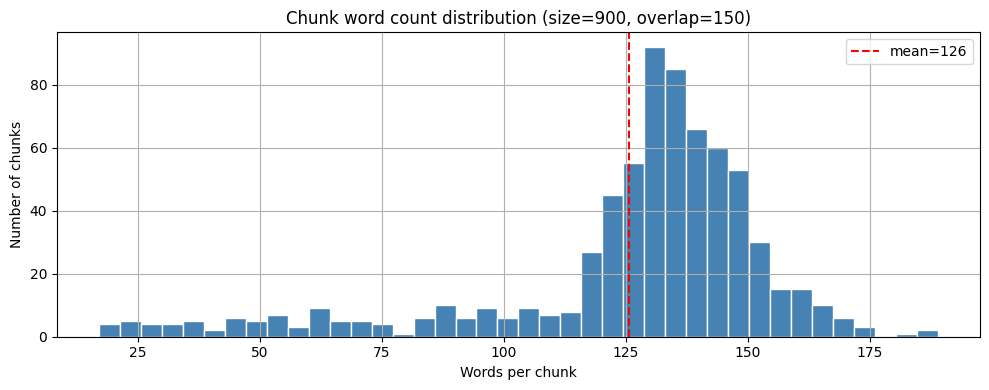

In [6]:
df = pd.DataFrame(baseline)
df['word_count'].hist(bins=40, figsize=(10, 4), color='steelblue', edgecolor='white')
plt.title('Chunk word count distribution (size=900, overlap=150)')
plt.xlabel('Words per chunk')
plt.ylabel('Number of chunks')
plt.axvline(df['word_count'].mean(), color='red', linestyle='--', label=f"mean={df['word_count'].mean():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
per_paper = (
    df.groupby(['method', 'year'])
    .agg(chunks=('chunk_id', 'count'), avg_words=('word_count', 'mean'))
    .sort_values('year')
    .round(1)
)
per_paper

,,chunks,avg_words
method,year,,
SRCNN,2014,88,132.0
VDSR,2015,49,129.4
SRGAN / SRResNet,2016,78,117.4
EDSR,2017,47,132.8
ESRGAN,2018,76,116.8
RCAN,2018,67,123.4
RDN,2018,63,131.5
Real-ESRGAN,2021,67,124.9
SwinIR,2021,79,126.9


In [8]:
# Find a chunk that mentions perceptual loss
hits = df[df['text'].str.contains('perceptual loss', case=False)]
print(f"Chunks mentioning 'perceptual loss': {len(hits)}\n")

if len(hits) > 0:
    sample = hits.iloc[0]
    print(f"chunk_id : {sample['chunk_id']}")
    print(f"method   : {sample['method']}  |  page {sample['page_number']}")
    print(f"words    : {sample['word_count']}")
    print('---')
    print(sample['text'][:600])

Chunks mentioning 'perceptual loss': 27

chunk_id : srgan_2016_p02_c00
method   : SRGAN / SRResNet  |  page 2
words    : 124
---
bicubic
SRResNet
SRGAN
original
(21.59dB/0.6423)
(23.53dB/0.7832)
(21.15dB/0.6868)
Figure 2: From left to right: bicubic interpolation, deep residual network optimized for MSE, deep residual generative
adversarial network optimized for a loss more sensitive to human perception, original HR image. Corresponding PSNR and
SSIM are shown in brackets. [4× upscaling]
perceptual difference between the super-resolved and orig-
inal image means that the recovered image is not photo-
realistic as defined by Ferwerda [16].
In this work we propose a super-resolution generative
adversarial network (SRGAN) 


In [9]:
# Chunks that end mid-sentence (no period/question/exclamation at end)
import re
bad_endings = df[~df['text'].str.strip().str[-1:].str.match(r'[.!?"\)]')]
pct = len(bad_endings) / len(df) * 100
print(f"Chunks with no sentence-final punctuation: {len(bad_endings)} ({pct:.1f}%)")
print("\nSample bad endings:")
for text in bad_endings['text'].head(3):
    print(f"  ...{text.strip()[-80:]}")
    print()

Chunks with no sentence-final punctuation: 567 (81.6%)

Sample bad endings:
  ... a lightweight structure, yet demonstrates state-of-the-art restoration quality,

  ...for any given low-resolution
pixel. In other words, it is an underdetermined in-

  ...aining samples provided.
The sparse-coding-based method [49], [50] is one of the



In [10]:
# Set your final choice here
FINAL_CHUNK_SIZE    = 900
FINAL_CHUNK_OVERLAP = 150

print(f'Final strategy: chunk_size={FINAL_CHUNK_SIZE}, chunk_overlap={FINAL_CHUNK_OVERLAP}')
print('If you change these after Day 5, delete vector_store/ and re-index!')

Final strategy: chunk_size=900, chunk_overlap=150
If you change these after Day 5, delete vector_store/ and re-index!


In [11]:
final_chunks = chunk_pages(pages, chunk_size=FINAL_CHUNK_SIZE, chunk_overlap=FINAL_CHUNK_OVERLAP)

save_chunks(final_chunks, '../data/processed/chunks')

print(f'Saved {len(final_chunks)} chunks')
print('Files written:')
print('  data/processed/chunks.json  (human-readable)')
print('  data/processed/chunks.pkl   (used by Day 5 embedder)')

Saved 695 chunks
Files written:
  data/processed/chunks.json  (human-readable)
  data/processed/chunks.pkl   (used by Day 5 embedder)
